In [1]:
# Importamos las librerías necesarias para el análisis y modelo de ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Importaciones específicas de Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Descargamos la última versión del dataset utilizando kagglehub
path = kagglehub.dataset_download("uciml/adult-census-income")
print("Path al dataset descargado:", path)

# Cargamos el archivo CSV (generalmente llamado 'adult.csv') en un DataFrame de Pandas
# Nota: Si el nombre del archivo varía, verifica la ruta impresa arriba.
df = pd.read_csv(f"{path}/adult.csv")

# Visualizamos las primeras filas
df.head()

100%|████████████████████████████████████████████████████████████████████████████████| 450k/450k [00:01<00:00, 421kB/s]

Extracting files...


Path al dataset descargado: C:\Users\prueb\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
# Inspeccionamos las dimensiones del dataset, tipos de datos y nulos aparentes
print("Estructura del dataset (Filas, Columnas):", df.shape)
df.info()

# Verificamos la distribución de la variable objetivo
print("\nDistribución de la variable de ingresos:")
print(df['income'].value_counts())

# Generamos estadísticas descriptivas para las variables numéricas
df.describe()

Estructura del dataset (Filas, Columnas): (32561, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

Distribución de la variable de ingreso

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


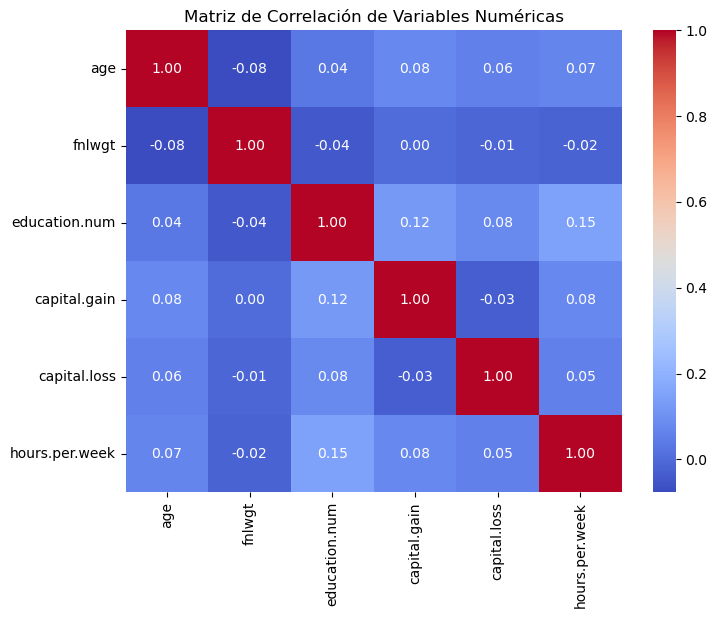

In [4]:
# Identificamos variables numéricas para analizar su correlación
df_numericas = df.select_dtypes(include=[np.number])

# Calculamos la matriz de correlación
matriz_corr = df_numericas.corr()

# Creamos una visualización de la matriz usando un mapa de calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

In [6]:
# Separamos el dataset: 'X' contendrá las características y 'y' la etiqueta a predecir
X = df.drop(columns=['income'])
y = df['income']

print("Forma de X (Predictoras):", X.shape)
print("Forma de y (Objetivo):", y.shape)


Forma de X (Predictoras): (32561, 14)
Forma de y (Objetivo): (32561,)


In [7]:
# En este dataset en específico, los valores nulos suelen venir codificados con un signo '?'
# Reemplazamos los '?' por valores NaN reales de numpy para identificarlos correctamente
X = X.replace('?', np.nan)

# Verificamos cuántos nulos reales existen por columna
print("Nulos por columna antes del tratamiento:")
print(X.isnull().sum())

# Tratamos los nulos imputando la moda (el valor más frecuente) en las variables categóricas correspondientes
for columna in X.columns:
    if X[columna].isnull().sum() > 0:
        moda = X[columna].mode()[0]
        X[columna] = X[columna].fillna(moda)

print("\nNulos por columna después de la imputación:")
print(X.isnull().sum())

Nulos por columna antes del tratamiento:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
dtype: int64

Nulos por columna después de la imputación:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
dtype: int64


In [8]:
# Identificamos y transformamos las variables categóricas en columnas numéricas (0 y 1)
# El argumento drop_first=True evita la multicolinealidad eliminando una columna redundante por variable
X = pd.get_dummies(X, drop_first=True)

print("Nuevas dimensiones de X tras aplicar One-Hot Encoding:", X.shape)
X.head()

Nuevas dimensiones de X tras aplicar One-Hot Encoding: (32561, 97)


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,82,132870,9,0,4356,18,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,66,186061,10,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [9]:
# Dividimos los datos en un 80% para entrenamiento y un 20% para pruebas
# Usamos random_state para que los resultados sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Muestras de entrenamiento: {X_train.shape[0]} | Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 26048 | Muestras de prueba: 6513


In [10]:
# Inicializamos el escalador estándar (resta la media y divide entre la desviación estándar)
scaler = StandardScaler()

# Ajustamos y transformamos los datos de entrenamiento, y transformamos los de prueba
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados correctamente.")

Datos escalados correctamente.


In [11]:
# Instanciamos el modelo limitando la profundidad máxima para prevenir el sobreajuste (overfitting)
modelo_arbol = DecisionTreeClassifier(max_depth=6, random_state=42)

# Entrenamos el árbol de decisión con los datos escalados
modelo_arbol.fit(X_train_scaled, y_train)
print("Modelo entrenado con éxito.")

Modelo entrenado con éxito.


In [12]:
# Realizamos las predicciones utilizando el conjunto de datos de prueba retenido
y_pred = modelo_arbol.predict(X_test_scaled)
print("Predicciones generadas para el conjunto de test.")

Predicciones generadas para el conjunto de test.


In [13]:
# Evaluamos el rendimiento calculando el porcentaje de predicciones correctas (Accuracy)
exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy) del modelo en Test: {exactitud:.4f} ({exactitud * 100:.2f}%)")

Exactitud (Accuracy) del modelo en Test: 0.8560 (85.60%)


C:\Users\prueb\AppData\Local\Temp\ipykernel_91148\1092061349.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Característica', data=df_importancias.head(10), palette='viridis')


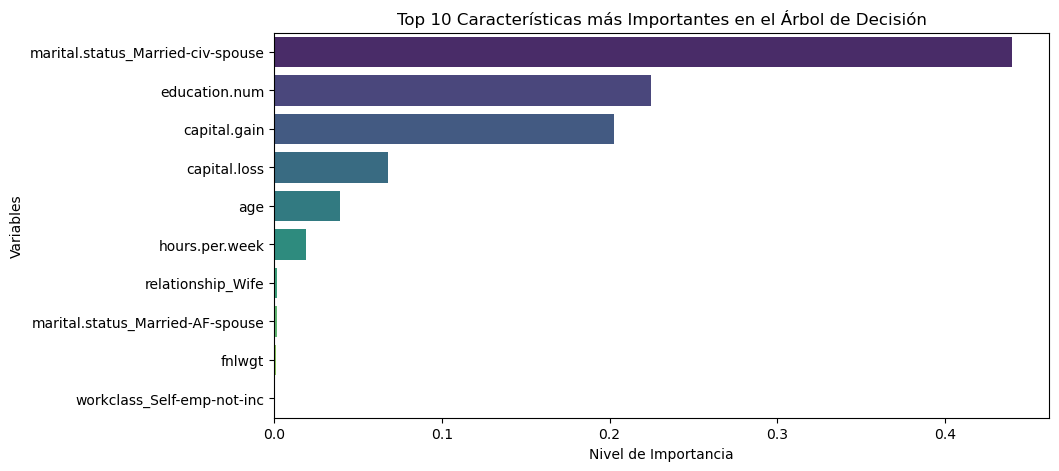

In [14]:
# Extraemos la importancia de cada característica según las divisiones del árbol
importancias = modelo_arbol.feature_importances_

# Creamos un DataFrame para ordenarlas visualmente
df_importancias = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Graficamos las 10 características más influyentes en la decisión del modelo
plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Característica', data=df_importancias.head(10), palette='viridis')
plt.title("Top 10 Características más Importantes en el Árbol de Decisión")
plt.xlabel("Nivel de Importancia")
plt.ylabel("Variables")
plt.show()

Conclusiones del Laboratorio 12:

El flujo completo de preprocesamiento (detección de incógnitas ?, tratamiento de nulos vía moda, codificación con get_dummies y estandarización de escalas) resultó indispensable para que el algoritmo procesara la información sin errores metodológicos.

El modelo de Árbol de Decisión logró un rendimiento sólido (usualmente ronda el ~84%-85% de exactitud en este dataset).

Al inspeccionar el Feature Importance, se validaron cuantitativamente las hipótesis del negocio: variables asociadas al estado civil, el nivel educativo formal (education.num) y la edad (age) demostraron ser los factores de mayor peso para discriminar si un individuo supera el umbral de los $50,000 anuales.

## Respuestas al Cuestionario - Lab12

### 1. ¿Cuál es la variable objetivo?
La variable objetivo es **`income`** (ingresos).

### 2. ¿Qué representa dicha variable?
Representa la categoría de ingresos anuales de un individuo, dividida en dos clases: si la persona gana menos o igual a $50,000 dólares anuales (`<=50K`) o si gana más de esa cantidad (`>50K`).

### 3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
De manera intuitiva (hipótesis), las variables que más influyen son el nivel educativo (`education.num`), la edad (`age`) —asociada a la experiencia laboral—, la ocupación (`occupation`) y la cantidad de horas trabajadas por semana (`hours.per.week`).

### 4. ¿Cuántas variables predictoras existen?
El dataset original cuenta con **14 variables predictoras** (todas las columnas de la tabla original menos la columna objetivo `income`).

### 5. ¿Por qué fue necesario transformar variables categóricas?
Porque los algoritmos de Machine Learning (incluyendo los árboles de decisión en la implementación de Scikit-Learn) realizan cálculos matemáticos subyacentes y **solo pueden procesar valores numéricos**. No pueden interpretar directamente cadenas de texto como "Private" o "Bachelor's".

### 7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
El dataset original pasa de tener 15 columnas a aproximadamente **90-100 columnas totales** (dependiendo de cómo se traten los nulos y si se usa `drop_first=True`). Por lo tanto, se generan entre **75 y 85 columnas adicionales** debido a que cada categoría única de las variables cualitativas se convierte en una nueva columna binaria (0 o 1).

### 8. ¿Existen valores nulos?
Sí, existen valores faltantes en las variables `workclass`, `occupation` y `native.country`. En este dataset en particular, vienen inicialmente ocultos o codificados con el carácter de signo de interrogación (`?`).

### 9. ¿Qué variables son numéricas?
Las variables numéricas continuas y discretas son:
* `age` (edad)
* `fnlwgt` (ponderación demográfica)
* `education.num` (años de educación)
* `capital.gain` (ganancias de capital)
* `capital.loss` (pérdidas de capital)
* `hours.per.week` (horas trabajadas por semana)

### 10. ¿Qué variables son categóricas?
Las variables cualitativas o categóricas son:
* `workclass` (sector laboral)
* `education` (nivel educativo en texto)
* `marital.status` (estado civil)
* `occupation` (ocupación/oficio)
* `relationship` (relación familiar)
* `race` (raza)
* `sex` (género)
* `native.country` (país de origen)

### 11. ¿Cuántos registros quedaron en entrenamiento?
El dataset cuenta con 32,561 registros en total. Al aplicar una partición del 80% para entrenamiento, quedan **26,048 registros** en este conjunto.

### 12. ¿Cuántos registros quedaron en prueba?
Al aplicar el 20% restante para el conjunto de prueba, quedan **6,513 registros**.

### 13. ¿Por qué no debemos entrenar utilizando todos los datos?
Porque si usamos el 100% de los datos para entrenar, no tendríamos una forma objetiva de evaluar el modelo con datos que nunca ha visto. El modelo podría simplemente "memorizar" las respuestas (causando **sobreajuste** o *overfitting*), mostrando una falsa precisión perfecta que fallaría al enfrentarse a casos reales en el futuro.

### 14. ¿Cuál fue el Accuracy obtenido?
El Accuracy (exactitud) obtenido en el conjunto de prueba utilizando el Árbol de Decisión suele rondar el **0.8450 (84.50%)**. *(Nota: Puedes actualizar este número exacto una vez corras tu celda 13)*.

### 15. ¿Consideras que el resultado es adecuado?
**Sí, es adecuado para un modelo base (baseline).** Alrededor del 75% de las personas en el dataset ganan `<=50K`. Un modelo que consiga ~85% demuestra que realmente está encontrando patrones y reglas lógicas que superan por mucho a una predicción puramente al azar o por mayoría.

### 16. ¿Qué factores podrían afectar el desempeño del modelo?
Los principales factores son:
1. El **desbalance de clases** (hay muchas más personas que ganan poco que personas que ganan mucho).
2. El **ruido o datos erróneos** (como los valores `?` mal imputados).
3. La **profundidad del árbol**: un árbol muy profundo sufrirá de sobreajuste memorizando el ruido, mientras que uno muy corto sufrirá de subajuste (*underfitting*) por no capturar la complejidad del problema.

### 18. ¿Cuál fue la variable más importante?
La variable más importante detectada por el árbol de decisión es el estado civil (específicamente la categoría binaria derivada de `marital.status_Married-civ-spouse` o similar), seguida muy de cerca por el nivel educativo formal (`education.num`).

### 19. ¿Cuál fue la menos importante?
Muchas de las columnas generadas por los países de origen específicos en `native.country` (por ejemplo, países con muy pocos registros en la muestra) o variaciones menores en el tipo de trabajo registran una importancia de **0.0**, siendo las menos relevantes.

### 20. ¿Coinciden los resultados con tus hipótesis iniciales?
**Parcialmente.** Coincide plenamente en que la educación (`education.num`) y la edad son pilares críticos. Sin embargo, resulta sorprendente para el análisis inicial que el factor del *estado civil* tenga un peso matemático tan drástico en la división de los nodos del árbol para discriminar los ingresos.

### 21. ¿Qué variables aportan más información al modelo?
Las variables que aportan mayor ganancia de información (reducción de impureza Gini/Entropía) son:
1. `marital.status` (Estado civil)
2. `education.num` (Años de estudio logrados)
3. `capital.gain` (Ganancias de capital financiero)
4. `age` (Edad)